In [1]:
import numpy as np

In [2]:
import pandas as pd 

In [75]:
df = pd.read_csv("placement.csv")

In [7]:
df.sample(5)

,cgpa,placement_exam_marks,placed
904,7.36,32.0,0
465,7.65,49.0,0
7,7.12,39.0,1
607,7.76,49.0,1
686,7.15,62.0,1


In [8]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

<Axes: xlabel='cgpa', ylabel='Count'>

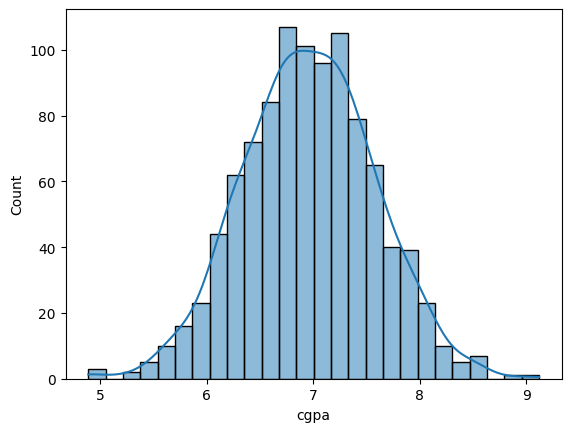

In [11]:
sns.histplot(df['cgpa'], kde = True)

<Axes: xlabel='placement_exam_marks', ylabel='Count'>

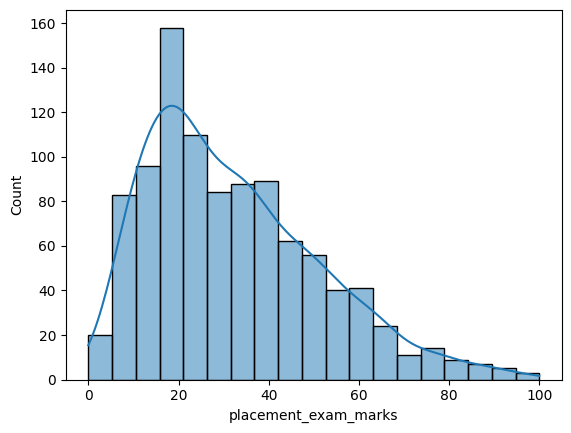

In [12]:
sns.histplot(df['placement_exam_marks'], kde = True)

In [13]:
# we cannot do z_score technique for placement_exam_marks because its skewed

In [16]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [17]:
# we have to find boundary values 

In [43]:
# highest allowed 
max = df['cgpa'].mean() + 3*df['cgpa'].std()
print(min)

5.113546374602832


In [44]:
min = df['cgpa'].mean() - 3*df['cgpa'].std()
print(max)

8.808933625397168


In [45]:
outliers = df[(df['cgpa'] > max) | (df['cgpa'] < min)]
outliers

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [46]:
# trimming

In [47]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [54]:
new_df_trim = df[(df['cgpa'] < max) & (df['cgpa'] > min)]

In [55]:
new_df_trim

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [57]:
# we can have another appraoch for doing trimming 
# we can calculate the actual Z_score of column and then accordingly ham rows select kare 
# if the Z_score is less than -3 or greater than 3 then we call it as a outlier 

In [58]:
df['cgpa_Zscore'] = (df['cgpa'] - df['cgpa'].mean())/ df['cgpa'].std()

In [59]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_Zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [60]:
df[(df['cgpa_Zscore'] > 3) | (df['cgpa_Zscore'] < -3) ]

,cgpa,placement_exam_marks,placed,cgpa_Zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [61]:
naya_trim_df = df[(df['cgpa_Zscore'] < 3) & (df['cgpa_Zscore'] > -3) ]

In [62]:
naya_trim_df

,cgpa,placement_exam_marks,placed,cgpa_Zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


In [64]:
# apparently we did the same thing 
# this was the brute force approach but did it in a simpler way pehle

In [65]:
# capping 

In [66]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()

In [67]:
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [68]:
upper_limit

np.float64(8.808933625397168)

In [69]:
lower_limit

np.float64(5.113546374602832)

In [70]:
# new piece of code 
# np.where(x, y, z)
# here x is the condition and y is agar vo condition true hua toh what to do, z is, if the condition is false hua then kya kare

In [78]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit, 
    np.where(
        df['cgpa'] < lower_limit, 
        lower_limit,
        df['cgpa']
    )
)

In [74]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64